# 6. Model Evaluation

This notebook evaluates the selected Gradient Boosting model on the held-out test set.The purpose of this stage is to determine whether the model's predicted probabilities provide a sufficiently useful ranking of 30-day readmission risk to support downstream patient prioritization and resource-allocation analysis.

Because the outcome is imbalanced, **PR-AUC remains the primary evaluation metric**, while **recall** is treated as the key operational metric. ROC-AUC, precision, F1-score, and accuracy are reported as supporting measures.

The held-out test set has not been used for model selection. Threshold analysis will be based on training or out-of-fold predictions to avoid using the test set for decision tuning.

## 6.1 Evaluation Setup

The modeling dataset, patient-aware train-test split, preprocessing pipeline, and selected Gradient Boosting model are reconstructed using the same specifications established during model development.

The held-out test set remains reserved for final evaluation and is not used for model selection or threshold tuning.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Load modeling data
df_model = pd.read_csv("../data/processed/modeling_data.csv")

# Restore administrative IDs as categorical variables
categorical_ids = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]
df_model[categorical_ids] = df_model[categorical_ids].astype(str)

# Patient-aware train-test split
X = df_model.drop(columns="readmitted_30")
y = df_model["readmitted_30"]
groups = df_model["patient_nbr"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = X_train["patient_nbr"].copy()
groups_test = X_test["patient_nbr"].copy()

X_train.drop(columns="patient_nbr", inplace=True)
X_test.drop(columns="patient_nbr", inplace=True)

# Preprocessing
numerical_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

dense_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_cols)
])

# Selected model
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=100,
        random_state=42
    ))
])

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(
    "Patient overlap:",
    len(set(groups_train) & set(groups_test))
)
print(f"Training readmission rate: {y_train.mean():.2%}")
print(f"Test readmission rate: {y_test.mean():.2%}")

Training shape: (81670, 33)
Test shape: (20093, 33)
Patient overlap: 0
Training readmission rate: 11.22%
Test readmission rate: 10.92%


## 6.2 Out-of-Fold Training Predictions

Before evaluating the final model on the held-out test set, out-of-fold predicted probabilities are generated from the training data using patient-aware cross-validation.

Each training encounter is therefore scored by a model that was not fitted on that encounter or on other encounters from the same validation fold. These probabilities provide a more reliable basis for threshold analysis than predictions generated from the same data used to fit the model.

The held-out test set remains untouched at this stage.

In [6]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = cross_val_predict(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF predictions generated:", len(oof_probabilities))
print("Minimum probability:", round(oof_probabilities.min(), 4))
print("Maximum probability:", round(oof_probabilities.max(), 4))
print("Mean probability:", round(oof_probabilities.mean(), 4))

OOF predictions generated: 81670
Minimum probability: 0.0012
Maximum probability: 0.7703
Mean probability: 0.1119


### Out-of-Fold Ranking Performance

PR-AUC and ROC-AUC are calculated from the out-of-fold probabilities to confirm that the model retains similar ranking performance when each training encounter is evaluated outside the fold used for model fitting.

In [7]:
oof_pr_auc = average_precision_score(
    y_train,
    oof_probabilities
)

oof_roc_auc = roc_auc_score(
    y_train,
    oof_probabilities
)

print(f"OOF PR-AUC: {oof_pr_auc:.3f}")
print(f"OOF ROC-AUC: {oof_roc_auc:.3f}")
print(f"Training prevalence: {y_train.mean():.3f}")

OOF PR-AUC: 0.226
OOF ROC-AUC: 0.675
Training prevalence: 0.112


The out-of-fold predictions achieved a **PR-AUC of 0.226** and a **ROC-AUC of 0.675**, closely matching the cross-validation performance observed during model development.

The PR-AUC is approximately twice the **11.2% readmission prevalence**, indicating that the model provides meaningful ranking information beyond the baseline rate of the positive class.

These results support using the out-of-fold probabilities for threshold analysis while preserving the held-out test set for final evaluation.

## 6.3 Final Test-Set Performance

The selected Gradient Boosting model is fitted on the complete training set and evaluated once on the held-out test set.Performance is assessed using predicted probabilities for ranking metrics and the default 0.50 threshold for classification metrics. The default-threshold results provide a reference point; alternative operating thresholds will be examined separately using the out-of-fold training predictions.

In [9]:
gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

test_probabilities = gradient_boosting_pipeline.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= 0.50
).astype(int)

Performance

In [10]:
test_results = pd.Series({
    "PR-AUC": average_precision_score(
        y_test, test_probabilities
    ),
    "ROC-AUC": roc_auc_score(
        y_test, test_probabilities
    ),
    "Recall": recall_score(
        y_test, test_predictions
    ),
    "Precision": precision_score(
        y_test, test_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test, test_predictions
    ),
    "Accuracy": accuracy_score(
        y_test, test_predictions
    )
})

test_results.round(3)

PR-AUC       0.231
ROC-AUC      0.678
Recall       0.008
Precision    0.607
F1           0.015
Accuracy     0.891
dtype: float64

OOF vs Test Table

In [11]:
performance_check = pd.DataFrame({
    "OOF Training": [
        oof_pr_auc,
        oof_roc_auc
    ],
    "Held-Out Test": [
        test_results["PR-AUC"],
        test_results["ROC-AUC"]
    ]
}, index=["PR-AUC", "ROC-AUC"])

performance_check.round(3)

,OOF Training,Held-Out Test
PR-AUC,0.226,0.231
ROC-AUC,0.675,0.678


The Gradient Boosting model achieved a **PR-AUC of 0.231** and **ROC-AUC of 0.678** on the held-out test set, slightly exceeding the corresponding out-of-fold results of 0.226 and 0.675. This consistency suggests that the model's ranking performance generalizes reasonably well to unseen patients.

At the default 0.50 classification threshold, however, **recall is only 0.8%**, meaning that very few actual 30-day readmissions are classified as positive. The relatively high precision of **60.7%** applies to this very small group of positive predictions and should therefore be interpreted alongside the low recall.

The **89.1% accuracy** largely reflects the class imbalance and is not sufficient for evaluating the model's usefulness in identifying readmission risk.

These findings reinforce the distinction between **risk ranking and binary classification**. The model provides useful separation in predicted risk, but the default 0.50 threshold is unsuitable for identifying a meaningful proportion of patients who are subsequently readmitted.

## 6.4 ROC and Precision–Recall Analysis

ROC and Precision–Recall curves are used to examine model performance across the full range of classification thresholds rather than at a single cutoff.

The ROC curve summarizes the model's ability to distinguish between readmitted and non-readmitted encounters. The Precision–Recall curve is particularly important in this analysis because 30-day readmissions represent only about 11% of encounters, making it more informative about performance on the minority class.

ROC Curve

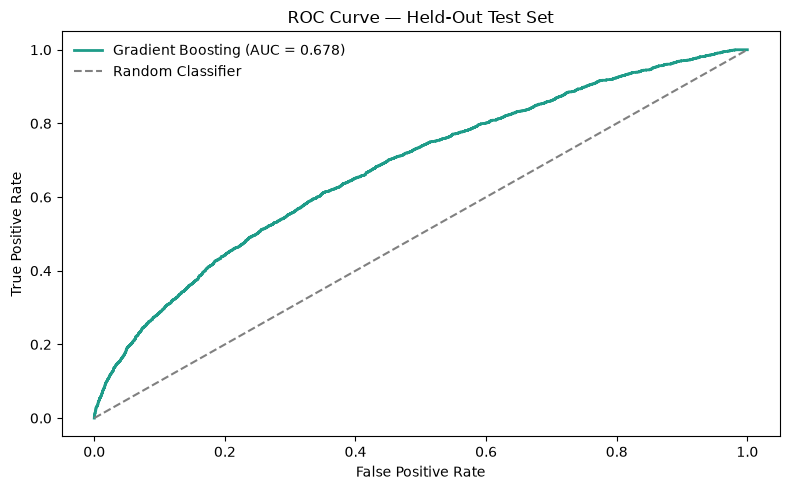

In [12]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color=plt.cm.viridis(0.55),
    label=f"Gradient Boosting (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Held-Out Test Set")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The model achieved a **PR-AUC of 0.231**, compared with a baseline readmission prevalence of approximately **10.9%** in the held-out test set. This indicates that the model provides meaningful information for ranking patients by readmission risk beyond the baseline prevalence.

The curve also highlights the trade-off between recall and precision: identifying a larger proportion of actual readmissions requires accepting more false-positive predictions.

This trade-off is operationally important because the appropriate operating point depends on how many patients the hospital can realistically support after discharge.